<a href="https://colab.research.google.com/github/anix07/PYTHON-FOR-DATA-ANALYSIS/blob/main/Urban_Mobility_Intelligence_Unit_(UMIU).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

#Setting up the coefficient matrix and constants
A = np.array([
    [2, -1, 1, 0],
    [1, 1, 0, 1],
    [-1, 0, 3, -1],
    [0, 1, 1, 1]
])

In [2]:
b = np.array([150, 420, 100, 380])

In [3]:
# Checking whether a unique solution exists
det_A = np.linalg.det(A)
print(f"Determinant of A: {det_A:.4f}")

Determinant of A: 6.0000


In [4]:
# Assessing numerical stability
cond_A = np.linalg.cond(A)
print(f"Condition number: {cond_A:.4f}")

Condition number: 10.7747


In [5]:
# Confirming full rank
rank_A = np.linalg.matrix_rank(A)
print(f"Rank of A: {rank_A}")

Rank of A: 4


In [6]:
# Solving the system
x = np.linalg.solve(A, b)
print(f"\nTraffic flows (vehicles per 10 min):")
for i, val in enumerate(x):
    print(f"  x{i+1} = {val:.4f}")


Traffic flows (vehicles per 10 min):
  x1 = 138.3333
  x2 = 225.0000
  x3 = 98.3333
  x4 = 56.6667


In [7]:
# Double-checking by computing the residual
residual = A @ x - b
print(f"\nResidual (Ax - b): {residual}")


Residual (Ax - b): [ 0.00000000e+00  0.00000000e+00 -2.84217094e-14  0.00000000e+00]


In [8]:
# Eigenvalue analysis for stability
eigenvalues = np.linalg.eigvals(A)
print(f"\nEigenvalues: {eigenvalues}")


Eigenvalues: [2.28737154+1.3499964j 2.28737154-1.3499964j 2.        +0.j
 0.42525693+0.j       ]


In [9]:
# Computing the inverse for sensitivity analysis
A_inv = np.linalg.inv(A)
print(f"\nInverse of A:\n{np.round(A_inv, 4)}")


Inverse of A:
[[ 0.1667  0.8333  0.1667 -0.6667]
 [-0.5     1.5     0.5    -1.    ]
 [ 0.1667 -0.1667  0.1667  0.3333]
 [ 0.3333 -1.3333 -0.6667  1.6667]]


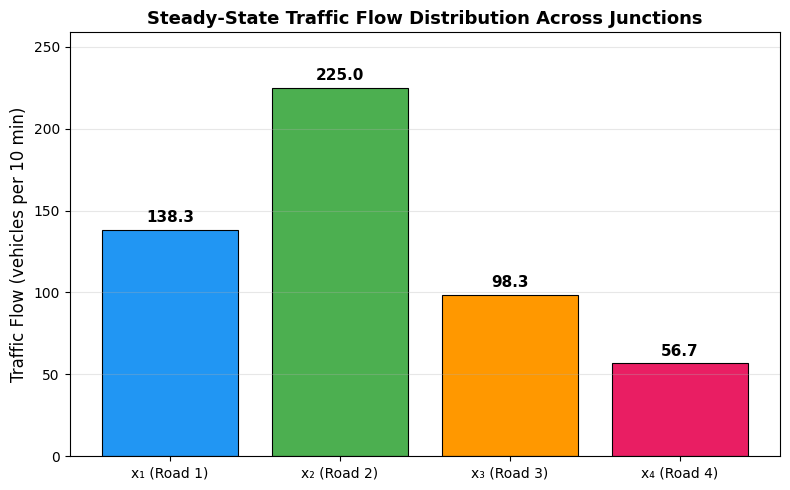

In [10]:
# Plotting the results
fig, ax = plt.subplots(figsize=(8, 5))
roads = ['x₁ (Road 1)', 'x₂ (Road 2)', 'x₃ (Road 3)', 'x₄ (Road 4)']
colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']
bars = ax.bar(roads, x, color=colors, edgecolor='black', linewidth=0.8)
for bar, val in zip(bars, x):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 3,
            f'{val:.1f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
ax.set_ylabel('Traffic Flow (vehicles per 10 min)', fontsize=12)
ax.set_title('Steady-State Traffic Flow Distribution Across Junctions',
             fontsize=13, fontweight='bold')
ax.set_ylim(0, max(x) * 1.15)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('traffic_flow.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
import numpy as np
from scipy.optimize import brentq
import matplotlib.pyplot as plt

In [12]:
# Time range for the analysis
t = np.linspace(0, 20, 500)

In [13]:
# Velocity function
v = 70 + 12 * np.cos(np.pi * t / 5) - 4 * np.sin(2 * np.pi * t / 5)

In [14]:
# Acceleration function (derivative of velocity)
a = -12 * (np.pi / 5) * np.sin(np.pi * t / 5) \
    - 4 * (2 * np.pi / 5) * np.cos(2 * np.pi * t / 5)

In [15]:
# Converting acceleration to m/s² for easier interpretation
a_ms2 = a * (1000 / 3600)

In [16]:
print(f"Velocity range: [{v.min():.2f}, {v.max():.2f}] km/h")
print(f"Acceleration range: [{a_ms2.min():.4f}, {a_ms2.max():.4f}] m/s²")

Velocity range: [56.06, 83.94] km/h
Acceleration range: [-1.7890, 3.4906] m/s²


In [17]:
# Identifying critical points where acceleration crosses zero
def accel_func(t_val):
    return -12 * (np.pi / 5) * np.sin(np.pi * t_val / 5) \
           - 4 * (2 * np.pi / 5) * np.cos(2 * np.pi * t_val / 5)

In [18]:
critical_times = []
for i in range(len(t) - 1):
    if a[i] * a[i+1] < 0:
        root = brentq(accel_func, t[i], t[i+1])
        critical_times.append(root)

In [19]:
print(f"\nCritical points where a(t) = 0:")
for ct in critical_times:
    v_ct = 70 + 12 * np.cos(np.pi * ct / 5) - 4 * np.sin(2 * np.pi * ct / 5)
    print(f"  t = {ct:.4f}s  →  v = {v_ct:.2f} km/h")


Critical points where a(t) = 0:
  t = 5.6993s  →  v = 56.06 km/h
  t = 9.3007s  →  v = 83.94 km/h
  t = 15.6993s  →  v = 56.06 km/h
  t = 19.3007s  →  v = 83.94 km/h


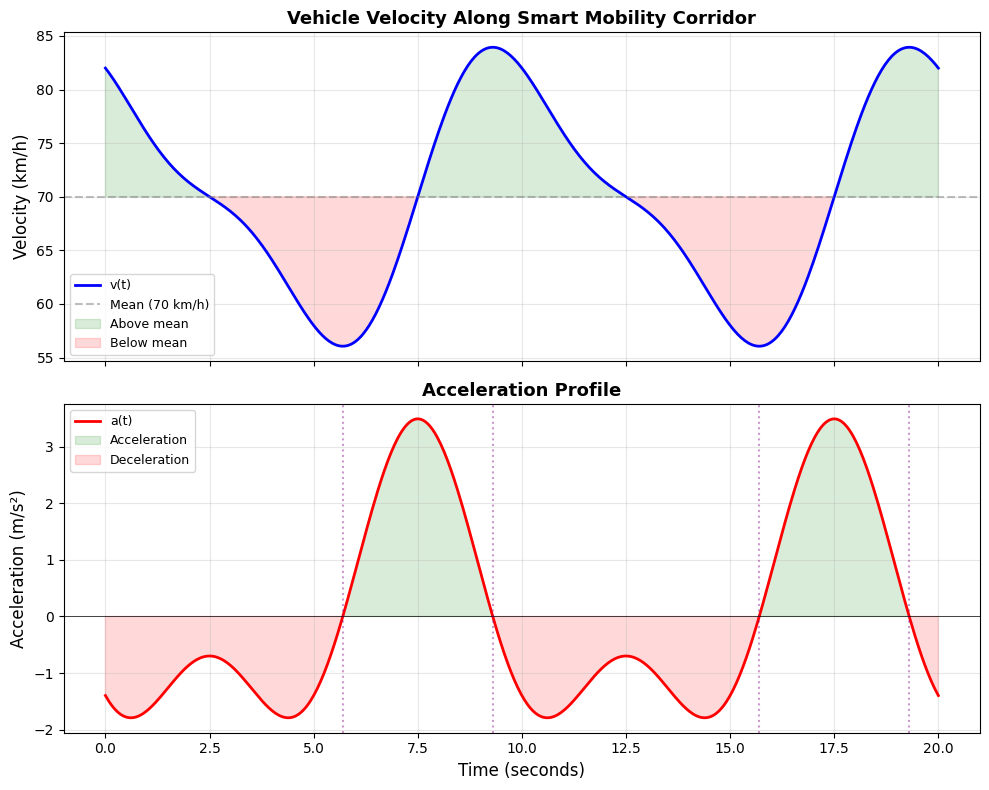

In [20]:
# Plotting velocity and acceleration together
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

ax1.plot(t, v, 'b-', linewidth=2, label='v(t)')
ax1.axhline(y=70, color='gray', linestyle='--', alpha=0.5, label='Mean (70 km/h)')
ax1.fill_between(t, 70, v, where=(v > 70), alpha=0.15, color='green', label='Above mean')
ax1.fill_between(t, 70, v, where=(v < 70), alpha=0.15, color='red', label='Below mean')
ax1.set_ylabel('Velocity (km/h)', fontsize=12)
ax1.set_title('Vehicle Velocity Along Smart Mobility Corridor',
              fontsize=13, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

ax2.plot(t, a_ms2, 'r-', linewidth=2, label='a(t)')
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax2.fill_between(t, 0, a_ms2, where=(a_ms2 > 0), alpha=0.15,
                 color='green', label='Acceleration')
ax2.fill_between(t, 0, a_ms2, where=(a_ms2 < 0), alpha=0.15,
                 color='red', label='Deceleration')
for ct in critical_times:
    ax2.axvline(x=ct, color='purple', linestyle=':', alpha=0.4)
ax2.set_xlabel('Time (seconds)', fontsize=12)
ax2.set_ylabel('Acceleration (m/s²)', fontsize=12)
ax2.set_title('Acceleration Profile', fontsize=13, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('velocity_acceleration.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

In [22]:
mu, sigma = 0.85, 0.25

In [23]:
# Computing key probabilities using the CDF
prob_rapid = stats.norm.cdf(0.5, mu, sigma)
prob_delayed = 1 - stats.norm.cdf(1.0, mu, sigma)
prob_critical = 1 - stats.norm.cdf(1.5, mu, sigma)
prob_typical = stats.norm.cdf(1.1, mu, sigma) - stats.norm.cdf(0.6, mu, sigma)

In [24]:
print(f"P(R < 0.5s)  = {prob_rapid:.6f}  ({prob_rapid*100:.2f}%)")
print(f"P(R > 1.0s)  = {prob_delayed:.6f}  ({prob_delayed*100:.2f}%)")
print(f"P(R > 1.5s)  = {prob_critical:.6f}  ({prob_critical*100:.2f}%)")
print(f"P(0.6<R<1.1) = {prob_typical:.6f}  ({prob_typical*100:.2f}%)")

P(R < 0.5s)  = 0.080757  (8.08%)
P(R > 1.0s)  = 0.274253  (27.43%)
P(R > 1.5s)  = 0.004661  (0.47%)
P(0.6<R<1.1) = 0.682689  (68.27%)


In [25]:
# Z-scores for the key thresholds
for threshold in [0.5, 1.0, 1.5]:
    z = (threshold - mu) / sigma
    print(f"Z({threshold}s) = {z:.2f}")

Z(0.5s) = -1.40
Z(1.0s) = 0.60
Z(1.5s) = 2.60


In [26]:
# Percentiles
for p in [5, 25, 50, 75, 95, 99]:
    val = stats.norm.ppf(p / 100, mu, sigma)
    print(f"{p}th percentile: {val:.4f}s")

5th percentile: 0.4388s
25th percentile: 0.6814s
50th percentile: 0.8500s
75th percentile: 1.0186s
95th percentile: 1.2612s
99th percentile: 1.4316s


In [27]:
p95 = stats.norm.ppf(0.95, mu, sigma)

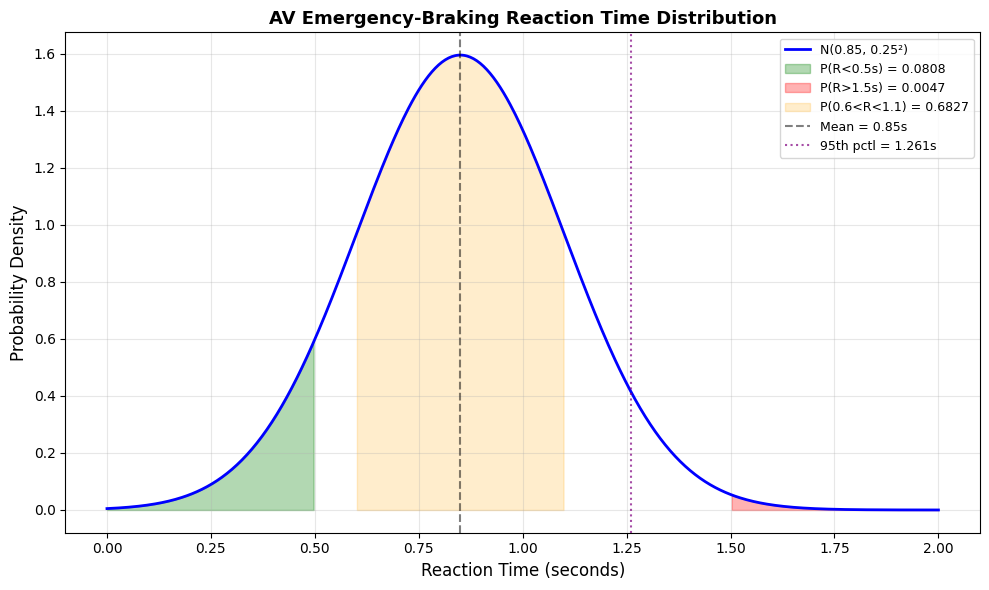

In [28]:
# Visualisation
fig, ax = plt.subplots(figsize=(10, 6))
x_range = np.linspace(0, 2.0, 500)
pdf_vals = stats.norm.pdf(x_range, mu, sigma)

ax.plot(x_range, pdf_vals, 'b-', linewidth=2, label='N(0.85, 0.25²)')
ax.fill_between(x_range, pdf_vals, where=(x_range < 0.5),
                alpha=0.3, color='green',
                label=f'P(R<0.5s) = {prob_rapid:.4f}')
ax.fill_between(x_range, pdf_vals, where=(x_range > 1.5),
                alpha=0.3, color='red',
                label=f'P(R>1.5s) = {prob_critical:.4f}')
ax.fill_between(x_range, pdf_vals,
                where=((x_range >= 0.6) & (x_range <= 1.1)),
                alpha=0.2, color='orange',
                label=f'P(0.6<R<1.1) = {prob_typical:.4f}')
ax.axvline(x=mu, color='black', linestyle='--', alpha=0.5,
           label=f'Mean = {mu}s')
ax.axvline(x=p95, color='purple', linestyle=':', alpha=0.7,
           label=f'95th pctl = {p95:.3f}s')

ax.set_xlabel('Reaction Time (seconds)', fontsize=12)
ax.set_ylabel('Probability Density', fontsize=12)
ax.set_title('AV Emergency-Braking Reaction Time Distribution',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='upper right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('reaction_time_dist.png', dpi=150, bbox_inches='tight')
plt.show()

In [29]:
import numpy as np
import matplotlib.pyplot as plt

In [30]:
speeds = np.array([49, 52, 55, 48, 50, 53, 57, 51, 54, 49, 52, 56])
speed_limit = 50

In [31]:
# Descriptive statistics
n = len(speeds)
mean_speed = np.mean(speeds)
std_speed = np.std(speeds, ddof=1)
se_speed = std_speed / np.sqrt(n)
median_speed = np.median(speeds)
q1, q3 = np.percentile(speeds, 25), np.percentile(speeds, 75)
exceeding = np.sum(speeds > speed_limit)

In [32]:
print("--- Descriptive Statistics ---")
print(f"n = {n}, Mean = {mean_speed:.4f}, Std = {std_speed:.4f}, SE = {se_speed:.4f}")
print(f"Median = {median_speed}, Q1 = {q1}, Q3 = {q3}, IQR = {q3-q1}")
print(f"Min = {speeds.min()}, Max = {speeds.max()}")
print(f"Exceeding limit: {exceeding}/{n} ({exceeding/n*100:.1f}%)")

--- Descriptive Statistics ---
n = 12, Mean = 52.1667, Std = 2.9181, SE = 0.8424
Median = 52.0, Q1 = 49.75, Q3 = 54.25, IQR = 4.5
Min = 48, Max = 57
Exceeding limit: 8/12 (66.7%)


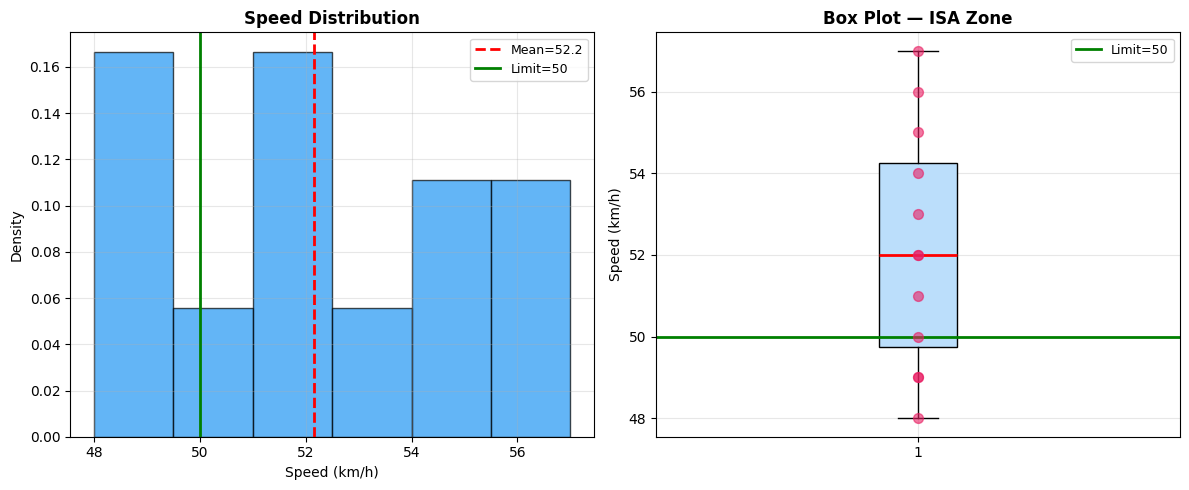

In [33]:
# Visualisation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.hist(speeds, bins=6, color='#2196F3', edgecolor='black', alpha=0.7, density=True)
ax1.axvline(x=mean_speed, color='red', linestyle='--', lw=2, label=f'Mean={mean_speed:.1f}')
ax1.axvline(x=speed_limit, color='green', lw=2, label=f'Limit={speed_limit}')
ax1.set_xlabel('Speed (km/h)'); ax1.set_ylabel('Density')
ax1.set_title('Speed Distribution', fontweight='bold'); ax1.legend(fontsize=9); ax1.grid(alpha=0.3)

ax2.boxplot(speeds, patch_artist=True, boxprops=dict(facecolor='#BBDEFB'),
            medianprops=dict(color='red', lw=2))
ax2.axhline(y=speed_limit, color='green', lw=2, label=f'Limit={speed_limit}')
ax2.scatter([1]*n, speeds, color='#E91E63', zorder=5, alpha=0.6, s=50)
ax2.set_ylabel('Speed (km/h)')
ax2.set_title('Box Plot — ISA Zone', fontweight='bold'); ax2.legend(fontsize=9); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('speed_compliance.png', dpi=150, bbox_inches='tight')
plt.show()

In [34]:
from scipy import stats

In [35]:
# One-sample t-test (one-tailed: is mean > 50?)
t_stat = (mean_speed - speed_limit) / se_speed
df = n - 1
p_one = 1 - stats.t.cdf(t_stat, df)
t_crit = stats.t.ppf(0.95, df)

In [36]:
print("--- Hypothesis Test ---")
print(f"H₀: μ = 50    H₁: μ > 50")
print(f"t = {t_stat:.4f}, df = {df}, p (one-tailed) = {p_one:.6f}")
print(f"t-critical (α=0.05) = {t_crit:.4f}")
print(f"Decision: {'REJECT H₀' if t_stat > t_crit else 'FAIL TO REJECT H₀'}")

--- Hypothesis Test ---
H₀: μ = 50    H₁: μ > 50
t = 2.5721, df = 11, p (one-tailed) = 0.012977
t-critical (α=0.05) = 1.7959
Decision: REJECT H₀


In [37]:
# 95% confidence interval
t_two = stats.t.ppf(0.975, df)
ci = (mean_speed - t_two * se_speed, mean_speed + t_two * se_speed)
print(f"95% CI: [{ci[0]:.4f}, {ci[1]:.4f}]")

95% CI: [50.3126, 54.0207]


In [38]:
# SciPy double-check
t_sp, p_sp = stats.ttest_1samp(speeds, speed_limit)
print(f"SciPy check: t = {t_sp:.4f}, p(two-tailed) = {p_sp:.6f}")

SciPy check: t = 2.5721, p(two-tailed) = 0.025953
